In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv("../data/market_data.csv", index_col=0, parse_dates=True)
prices.head()

,EEM,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ
Date,,,,,,,,
2005-01-03,14.562672,43.020000,48.275040,48.074734,33.695393,81.606010,44.909607,22.788921
2005-01-04,14.114314,42.740002,47.240173,47.804935,33.081184,80.608818,44.438942,22.446411
2005-01-05,13.941526,42.669998,46.295971,47.843472,32.876442,80.052551,44.676788,21.700241
2005-01-06,13.932051,42.150002,46.541481,47.877739,32.714371,80.459572,44.707146,21.867413
2005-01-07,13.959031,41.840000,46.024048,47.856297,32.884979,80.344261,44.808369,21.818478


In [3]:
returns = np.log(prices / prices.shift(1))
returns = returns.dropna()

returns.head()

,EEM,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ
Date,,,,,,,,
2005-01-04,-0.031272,-0.006530,-0.021670,-0.005628,-0.018396,-0.012295,-0.010536,-0.015144
2005-01-05,-0.012318,-0.001639,-0.020190,0.000806,-0.006208,-0.006925,0.005338,-0.033807
2005-01-06,-0.000680,-0.012261,0.005289,0.000716,-0.004942,0.005072,0.000679,0.007674
2005-01-07,0.001935,-0.007382,-0.011180,-0.000448,0.005202,-0.001434,0.002262,-0.002240
2005-01-10,0.001252,0.002626,0.010124,-0.001701,-0.000519,0.004716,0.001580,-0.003182


In [4]:
volatility = returns.rolling(20).std()
volatility.columns = [c + "_vol20" for c in volatility.columns]

volatility.head()

,EEM_vol20,GLD_vol20,IWM_vol20,LQD_vol20,QQQ_vol20,SPY_vol20,TLT_vol20,VNQ_vol20
Date,,,,,,,,
2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
momentum = prices.pct_change(50)
momentum.columns = [c + "_mom50" for c in momentum.columns]

momentum.head()

,EEM_mom50,GLD_mom50,IWM_mom50,LQD_mom50,QQQ_mom50,SPY_mom50,TLT_mom50,VNQ_mom50
Date,,,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#synthetic market index 
market = prices.mean(axis=1)

In [7]:
ma50 = market.rolling(50).mean()
ma200 = market.rolling(200).mean()

In [8]:
market_returns = np.log(market / market.shift(1))

In [9]:
cum_returns = (1 + market_returns.fillna(0)).cumprod()
peak = cum_returns.cummax()

drawdown = cum_returns / peak - 1

In [10]:
market_features = pd.DataFrame({
    "market_price": market,
    "market_return": market_returns,
    "ma50": ma50,
    "ma200": ma200,
    "drawdown": drawdown
})

In [11]:
conditions = [
    (market_features["market_price"] > market_features["ma200"]) & (market_features["market_return"] > 0),
    (market_features["market_price"] < market_features["ma200"]) & (market_features["market_return"] < 0)
]

choices = ["bull", "bear"]
market_features["regime"] = np.select(conditions, choices, default="sideways")

In [12]:
dataset = pd.concat([returns, volatility, momentum, market_features],axis=1).dropna()

/var/folders/4l/ps8gtn856617_4nt7nzqdfm80000gn/T/ipykernel_12136/2986745836.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  dataset = pd.concat([returns, volatility, momentum, market_features],axis=1).dropna()


In [13]:
dataset.to_csv("../data/processed_data.csv")
print("processed dataset")

processed dataset


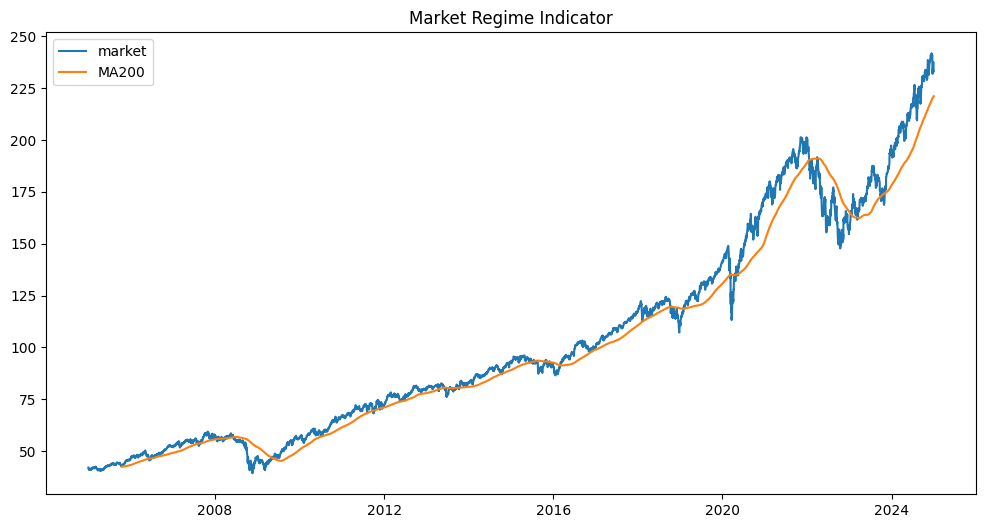

In [14]:
plt.figure(figsize=(12,6))
plt.plot(market, label="market")
plt.plot(ma200, label="MA200")

plt.legend()
plt.title("Market Regime Indicator")
plt.show()

In [15]:
dataset["regime"].value_counts()

regime
bull        2251
sideways    2091
bear         491
Name: count, dtype: int64